In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import nltk
import time
from imblearn.over_sampling import SMOTE

In [2]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
# Define the path to the large JSON file
file_path = "E:/yelp_academic_dataset_review.json"

In [4]:
# Define relevant columns for processing
relevant_columns = ['review_id', 'user_id', 'business_id', 'stars', 'text']

In [5]:
# Initialize a list to store processed chunks
sample_size = 300000
processed_reviews = []

In [6]:
try:
    # Read the JSON file in chunks and sample data
    chunk_size = 100000
    for chunk in pd.read_json(file_path, lines=True, chunksize=chunk_size):
        chunk = chunk[relevant_columns]
        if len(processed_reviews) < sample_size:
            sampled_chunk = chunk.sample(frac=1, random_state=42).head(sample_size - len(processed_reviews))
            processed_reviews.append(sampled_chunk)
        if sum(len(data) for data in processed_reviews) >= sample_size:
            break

    # Combine sampled chunks into a single DataFrame
    data = pd.concat(processed_reviews, ignore_index=True)
    print(f"Sampled {len(data)} rows from the dataset.")
    
    # Check for null values
    print("\nChecking for missing values...")
    missing_values = data.isnull().sum()
    print(missing_values)

    # Drop rows with null values in relevant columns
    relevant_columns_used = ['text', 'stars']
    print(f"\nColumns used for modeling: {relevant_columns_used}")
    data = data.dropna(subset=relevant_columns_used)
    print(f"Data after dropping missing values: {data.shape}")

except Exception as e:
    print(f"An error occurred while sampling the data: {e}")

Sampled 300000 rows from the dataset.

Checking for missing values...
review_id      0
user_id        0
business_id    0
stars          0
text           0
dtype: int64

Columns used for modeling: ['text', 'stars']
Data after dropping missing values: (300000, 5)


In [7]:
# Step 1: Data Preprocessing
# Map ratings to Positive (4-5), Neutral (3), Negative (1-2)
def map_rating(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

data['sentiment'] = data['stars'].apply(map_rating)

In [8]:
# Define a lemmatizer
lemmatizer = WordNetLemmatizer()

In [9]:
# Handle contractions (e.g., "won't" -> "will not")
def expand_contractions(text):
    contractions = {
        "won't": "will not",
        "can't": "cannot",
        "n't": " not",
        "'re": " are",
        "'s": " is",
        "'d": " would",
        "'ll": " will",
        "'t": " not",
        "'ve": " have",
        "'m": " am"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    return text

In [10]:
# Remove slang words
def remove_slang(text):
    slang_dict = {
        "u": "you",
        "r": "are",
        "ur": "your",
        "idk": "I do not know",
        "btw": "by the way",
        "omg": "oh my god",
        "brb": "be right back",
        "bff": "best friend forever",
        "smh": "shaking my head",
        "tbh": "to be honest",
        "lmao": "laughing my ass off",
        "lol": "laughing out loud",
        "wtf": "what the heck",
        "rofl": "rolling on the floor laughing",
        "omw": "on my way",
        "fyi": "for your information",
        "nvm": "never mind",
        "tbt": "throwback Thursday",
        "imo": "in my opinion",
        "irl": "in real life"
    }
    for slang, full_form in slang_dict.items():
        text = re.sub(rf'\b{slang}\b', full_form, text)
    return text

In [11]:
# Cleaning text data with lemmatization, contraction handling, slang removal, and stopwords removal
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = expand_contractions(text)
    text = remove_slang(text)
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text

In [12]:
# Ensure the function definitions are complete before this line
try:
    data['cleaned_text'] = data['text'].apply(clean_text)
except Exception as e:
    print(f"An error occurred during text cleaning: {e}")

In [13]:
# Split data into training and test sets
X = data['cleaned_text']
y = data['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [14]:
# Step 2: Feature Engineering
# One-Hot Encoding Unigram + Bigram
one_hot_vectorizer = CountVectorizer(ngram_range=(1, 2), binary=True, max_features=50000, min_df=5)
X_train_onehot_unibigram = one_hot_vectorizer.fit_transform(X_train)
X_test_onehot_unibigram = one_hot_vectorizer.transform(X_test)

Class Distribution Before Balancing:
sentiment
Positive    166757
Negative     46052
Neutral      27191
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_18040\1859964081.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette="viridis")


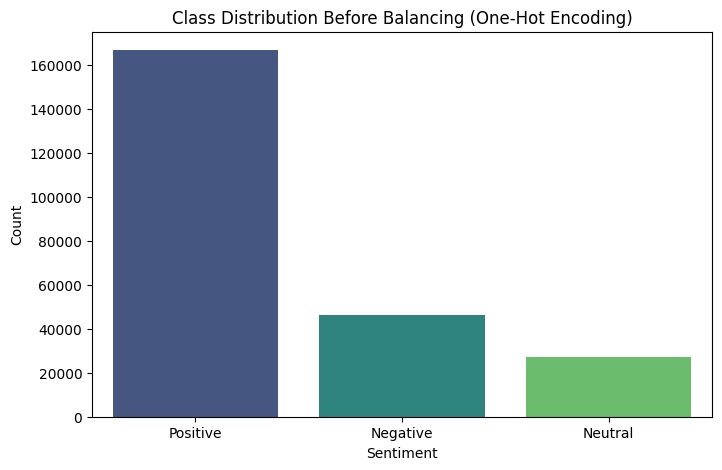

In [15]:
# Check class imbalance before balancing
class_distribution = y_train.value_counts()
print("Class Distribution Before Balancing:")
print(class_distribution)
plt.figure(figsize=(8, 5))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette="viridis")
plt.title("Class Distribution Before Balancing (One-Hot Encoding)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [16]:
# Step 3: Model Training, Cross-Validation, and Saving

# Helper function for evaluation
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print("Training Classification Report:")
    print(classification_report(y_train, y_train_pred))
    print("Test Classification Report:")
    print(classification_report(y_test, y_test_pred))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Multiclass ROC Curve and AUC
    y_test_binarized = label_binarize(y_test, classes=['Negative', 'Neutral', 'Positive'])
    y_test_pred_proba = model.predict_proba(X_test)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(y_test_binarized.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_test_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    for i, label in enumerate(['Negative', 'Neutral', 'Positive']):
        plt.plot(fpr[i], tpr[i], label=f"{label} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
    plt.title("Multiclass ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


Evaluation Before Balancing:
Training Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.76      0.76     46052
     Neutral       0.43      0.64      0.52     27191
    Positive       0.95      0.87      0.91    166757

    accuracy                           0.83    240000
   macro avg       0.71      0.76      0.73    240000
weighted avg       0.86      0.83      0.84    240000

Test Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.75      0.75     11513
     Neutral       0.39      0.59      0.47      6798
    Positive       0.94      0.87      0.90     41689

    accuracy                           0.81     60000
   macro avg       0.69      0.73      0.71     60000
weighted avg       0.84      0.81      0.82     60000

Confusion Matrix:
[[ 8593  2436   484]
 [ 1166  4003  1629]
 [ 1736  3844 36109]]


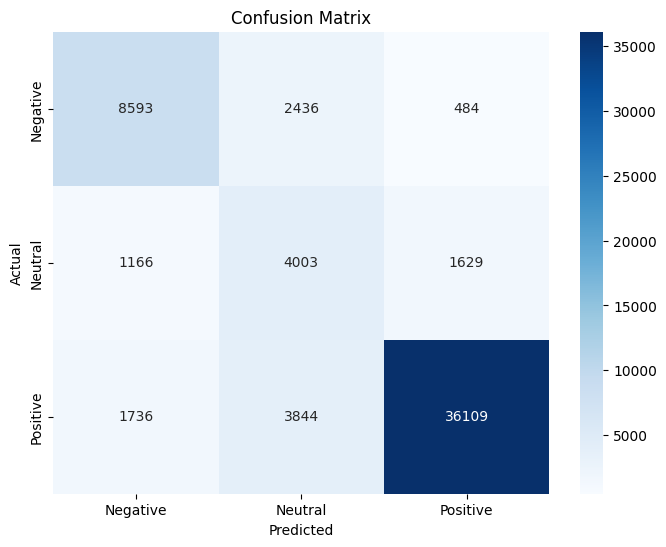

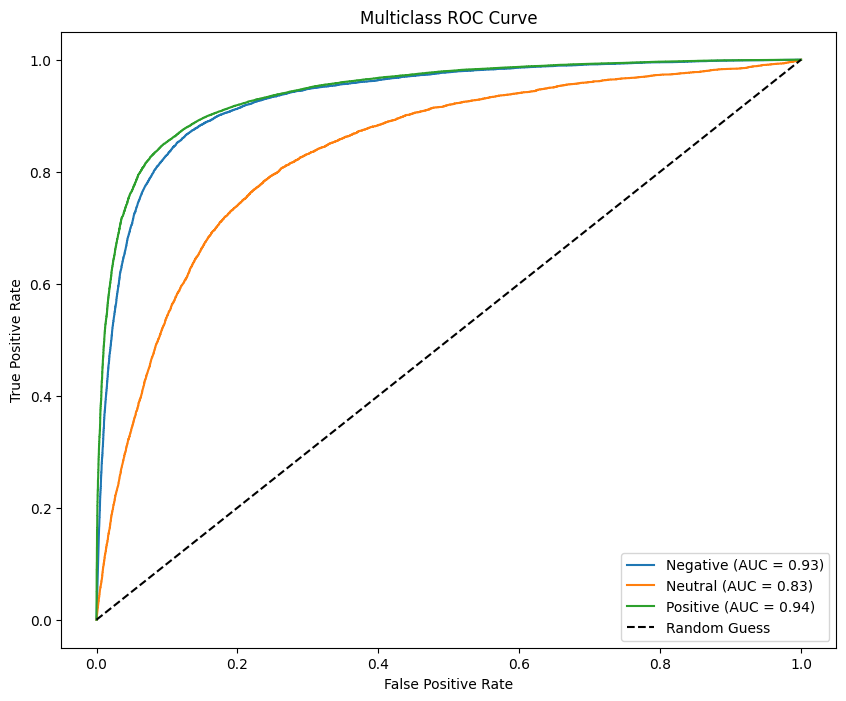

In [17]:
# Evaluate Before Balancing
print("\nEvaluation Before Balancing:")
nb_onehot_imbalanced = MultinomialNB()
nb_onehot_imbalanced.fit(X_train_onehot_unibigram, y_train)
evaluate_model(nb_onehot_imbalanced, X_train_onehot_unibigram, X_test_onehot_unibigram, y_train, y_test)

In [18]:
# Apply SMOTE for oversampling
smote = SMOTE(random_state=42)
X_train_onehot_balanced, y_train_balanced = smote.fit_resample(X_train_onehot_unibigram, y_train)

Class Distribution After Balancing:
sentiment
Positive    166757
Negative    166757
Neutral     166757
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_18040\3457663557.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=balanced_class_distribution.index, y=balanced_class_distribution.values, palette="viridis")


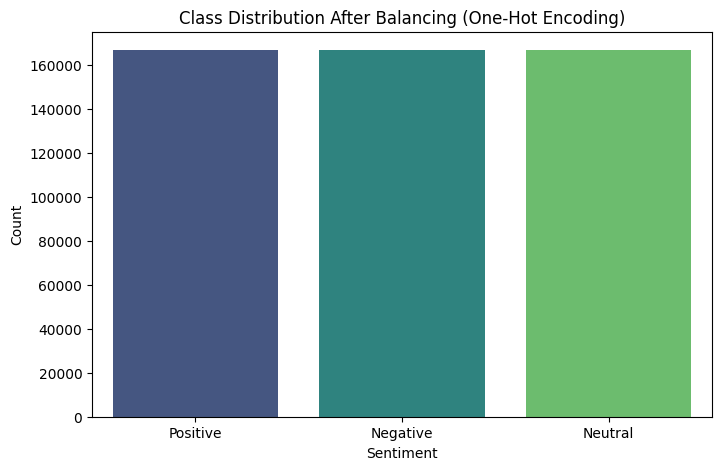

In [19]:
# Check class distribution after balancing
balanced_class_distribution = pd.Series(y_train_balanced).value_counts()
print("Class Distribution After Balancing:")
print(balanced_class_distribution)
plt.figure(figsize=(8, 5))
sns.barplot(x=balanced_class_distribution.index, y=balanced_class_distribution.values, palette="viridis")
plt.title("Class Distribution After Balancing (One-Hot Encoding)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [20]:
# Perform Grid Search for Hyperparameter Tuning
def perform_grid_search():
    param_grid = {
        'alpha': [0.1, 0.5, 1.0],  # Add more values to fine-tune smoothing
        'fit_prior': [True, False]
    }
    grid_search = GridSearchCV(estimator=MultinomialNB(), param_grid=param_grid, scoring='accuracy', cv=5, n_jobs=-1)
    grid_search.fit(X_train_onehot_balanced, y_train_balanced)
    print("Best Parameters from Grid Search:")
    print(grid_search.best_params_)
    print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
    return grid_search.best_estimator_

In [21]:
# Perform Grid Search
start_time = time.time()
nb_best_model = perform_grid_search()
print(f"Grid Search Time: {time.time() - start_time:.2f} seconds")

Best Parameters from Grid Search:
{'alpha': 0.1, 'fit_prior': False}
Best Cross-Validation Score: 0.7231
Grid Search Time: 48.95 seconds



Evaluation with Best Model from Grid Search:
Training Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.88      0.75    166757
     Neutral       0.71      0.53      0.61    166757
    Positive       0.92      0.84      0.88    166757

    accuracy                           0.75    500271
   macro avg       0.76      0.75      0.75    500271
weighted avg       0.76      0.75      0.75    500271

Test Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.75      0.74     11513
     Neutral       0.36      0.62      0.45      6798
    Positive       0.95      0.84      0.89     41689

    accuracy                           0.80     60000
   macro avg       0.68      0.74      0.70     60000
weighted avg       0.84      0.80      0.81     60000

Confusion Matrix:
[[ 8690  2506   317]
 [ 1244  4201  1353]
 [ 1911  4965 34813]]


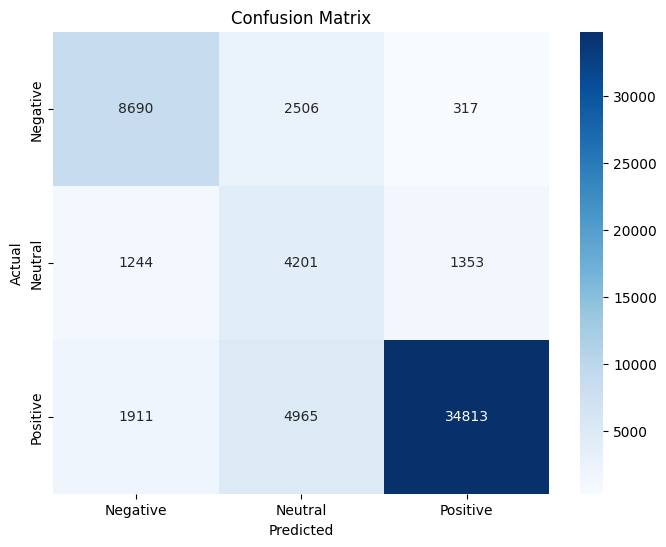

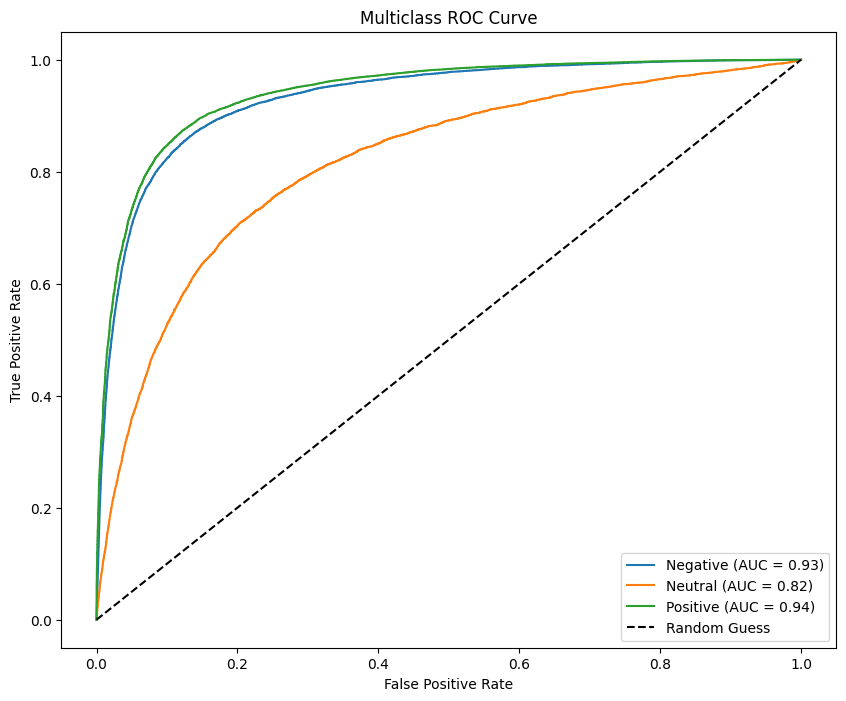

In [22]:
# Evaluate the best model
print("\nEvaluation with Best Model from Grid Search:")
evaluate_model(nb_best_model, X_train_onehot_balanced, X_test_onehot_unibigram, y_train_balanced, y_test)

In [23]:
# Save the best model to a pickle file
with open("naive_bayes_onehot_best_model.pkl", "wb") as model_file:
    pickle.dump(nb_best_model, model_file)
print("Best Naive Bayes model saved as naive_bayes_onehot_best_model.pkl")

Best Naive Bayes model saved as naive_bayes_onehot_best_model.pkl


In [24]:
# Load the saved best model and test on new data
print("\nLoading the best saved model...")
with open("naive_bayes_onehot_best_model.pkl", "rb") as model_file:
    loaded_best_model = pickle.load(model_file)


Loading the best saved model...



Testing the loaded best model on the test set:
Training Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.88      0.75    166757
     Neutral       0.71      0.53      0.61    166757
    Positive       0.92      0.84      0.88    166757

    accuracy                           0.75    500271
   macro avg       0.76      0.75      0.75    500271
weighted avg       0.76      0.75      0.75    500271

Test Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.75      0.74     11513
     Neutral       0.36      0.62      0.45      6798
    Positive       0.95      0.84      0.89     41689

    accuracy                           0.80     60000
   macro avg       0.68      0.74      0.70     60000
weighted avg       0.84      0.80      0.81     60000

Confusion Matrix:
[[ 8690  2506   317]
 [ 1244  4201  1353]
 [ 1911  4965 34813]]


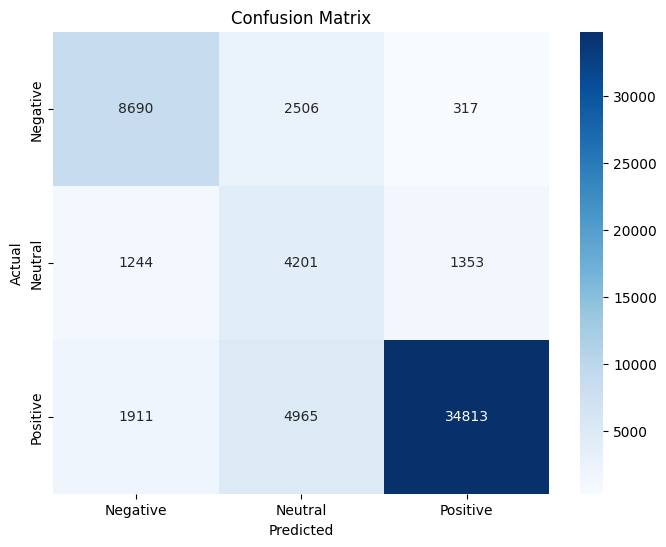

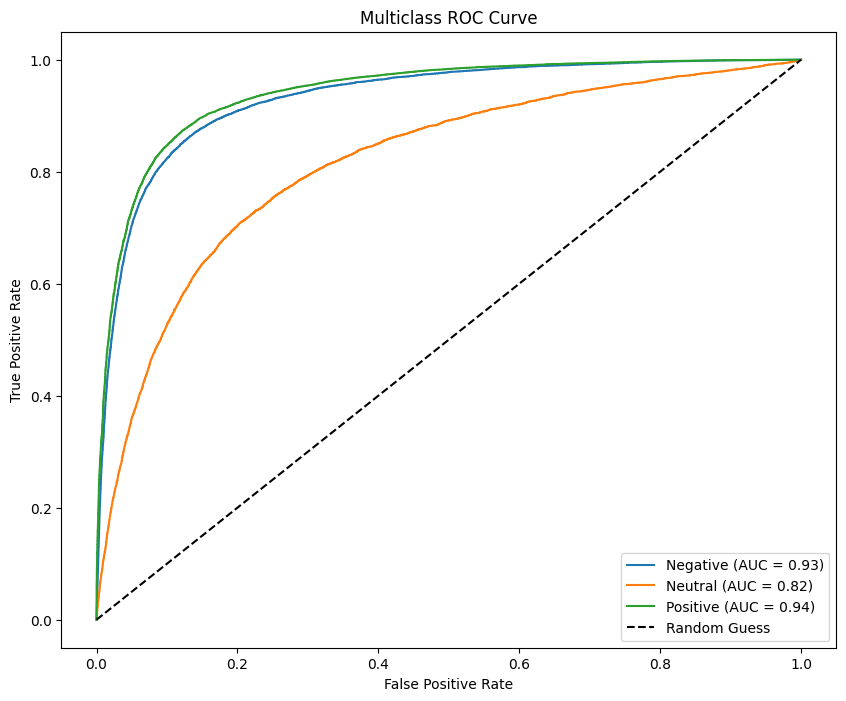

In [25]:
print("\nTesting the loaded best model on the test set:")
evaluate_model(loaded_best_model, X_train_onehot_balanced, X_test_onehot_unibigram, y_train_balanced, y_test)